# Week 06 - Boosting and SHAP-Guided Model Revision

**DMML - Data Mining & Machine Learning**  
**Due:** End of Week 07  
**Estimated time:** 3-4 hours

This notebook is self-contained except for SHAP. You will train boosted tree models, use SHAP values to understand what the model relies on, then change the modelling pipeline based on that explanation.


## What You Are Building

This week has five required functions:

1. `split_data(X, y, test_size, random_state)` - stratified train/test split.
2. `evaluate_classifiers(models, X_train, X_test, y_train, y_test)` - compare tree and boosting models numerically.
3. `compute_shap_importance(model, X_explain, feature_names)` - turn SHAP values into a global feature-importance table.
4. `evaluate_feature_subset(model, X_train, X_test, y_train, y_test, selected_features)` - retrain using only SHAP-selected features.
5. `make_benchmark_long(results, week, dataset, task_type, target, split)` - append results to the reusable benchmark format.

The point of SHAP here is not to decorate the notebook with an interpretability figure. You will use SHAP to decide which features to keep, retrain a smaller model, and test whether the explanation leads to a useful simplification.


In [1]:
# Imports - keep this cell stable
import warnings
from time import perf_counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.datasets import load_breast_cancer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42
TEST_SIZE = 0.25
TOP_K_FEATURES = 6


## SHAP Requirement

This exercise requires SHAP. If the import below fails, install it in your environment before continuing.

```bash
pip install shap
```

SHAP can be computationally heavier than ordinary model fitting. This notebook explains only the test set, which is small enough for the exercise.


In [12]:
try:
    import shap
except ImportError as exc:
    raise ImportError("This notebook requires shap. Install it with: pip install shap") from exc


## Dataset

The Breast Cancer Wisconsin dataset is a binary classification problem with numeric tabular features. The target classes are malignant and benign diagnoses.


In [2]:
data = load_breast_cancer(as_frame=True)
X = data.data
# sklearn encodes malignant=0, benign=1. Keep that encoding and interpret it carefully.
y = data.target.rename("diagnosis")
feature_names = list(X.columns)
class_names = list(data.target_names)

print(X.shape)
print("Target classes:", dict(enumerate(class_names)))
display(X.head())
display(y.value_counts().sort_index().rename(index=dict(enumerate(class_names))))


(569, 30)
Target classes: {0: np.str_('malignant'), 1: np.str_('benign')}


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


diagnosis
malignant    212
benign       357
Name: count, dtype: int64

## Task 1 - Stratified Split

Implement `split_data(X, y, test_size, random_state)`.

Return `(X_train, X_test, y_train, y_test)`. Use stratification so both classes are represented in train and test.


In [3]:
def split_data(
    X: pd.DataFrame,
    y: pd.Series,
    test_size: float = TEST_SIZE,
    random_state: int = RANDOM_STATE,
):
    """Create a stratified train/test split for classification."""
    return train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y,
    )


In [4]:
# Self-check: Task 1
X_train, X_test, y_train, y_test = split_data(X, y)

assert len(X_train) == len(y_train)
assert len(X_test) == len(y_test)
assert set(y_train.unique()) == set(y.unique())
assert set(y_test.unique()) == set(y.unique())
assert X_train.shape[1] == X.shape[1]

print("Task 1 passed")


Task 1 passed


## Task 2 - Evaluate Tree and Boosting Models

Implement `evaluate_classifiers(models, X_train, X_test, y_train, y_test)`.

Output columns:

- `model`
- `accuracy`
- `f1_macro`
- `roc_auc`
- `fit_time_sec`

Fit each model on the training set and evaluate on the test set. Sort by `f1_macro` descending.


In [5]:
def evaluate_classifiers(models: dict, X_train, X_test, y_train, y_test) -> pd.DataFrame:
    """Fit classifiers and return comparable held-out test metrics."""
    rows = []

    for name, model in models.items():
        start = perf_counter()
        model.fit(X_train, y_train)
        fit_time = perf_counter() - start
        predictions = model.predict(X_test)
        probabilities = model.predict_proba(X_test)[:, 1]
        rows.append(
            {
                "model": name,
                "accuracy": float(accuracy_score(y_test, predictions)),
                "f1_macro": float(f1_score(y_test, predictions, average="macro")),
                "roc_auc": float(roc_auc_score(y_test, probabilities)),
                "fit_time_sec": float(fit_time),
            }
        )

    columns = ["model", "accuracy", "f1_macro", "roc_auc", "fit_time_sec"]
    return pd.DataFrame(rows, columns=columns).sort_values("f1_macro", ascending=False).reset_index(drop=True)


In [6]:
# Self-check: Task 2
models = {
    "dummy_most_frequent": DummyClassifier(strategy="most_frequent"),
    "decision_tree_depth_3": DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE),
    "random_forest_200": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    "gradient_boosting_100": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=RANDOM_STATE),
    "hist_gradient_boosting": HistGradientBoostingClassifier(random_state=RANDOM_STATE),
}

model_results = evaluate_classifiers(models, X_train, X_test, y_train, y_test)

assert isinstance(model_results, pd.DataFrame)
assert list(model_results.columns) == ["model", "accuracy", "f1_macro", "roc_auc", "fit_time_sec"]
assert len(model_results) == len(models)
assert model_results["f1_macro"].is_monotonic_decreasing
assert model_results[["accuracy", "f1_macro", "roc_auc", "fit_time_sec"]].notna().all().all()
assert model_results.loc[model_results["model"] == "gradient_boosting_100", "f1_macro"].iloc[0] > 0.85

print("Task 2 passed")
model_results


Task 2 passed


,model,accuracy,f1_macro,roc_auc,fit_time_sec
0,hist_gradient_boosting,0.965035,0.962067,0.994130,0.133889
1,random_forest_200,0.958042,0.954670,0.994864,0.214480
2,gradient_boosting_100,0.958042,0.954284,0.992453,0.284271
3,decision_tree_depth_3,0.944056,0.939560,0.946331,0.004748
4,dummy_most_frequent,0.629371,0.386266,0.500000,0.000740


## Choose the Model to Explain

For SHAP, we will explain the `gradient_boosting_100` model even if another model slightly wins the benchmark. This keeps the interpretation tied to the boosting topic and uses a tree model that SHAP handles well.


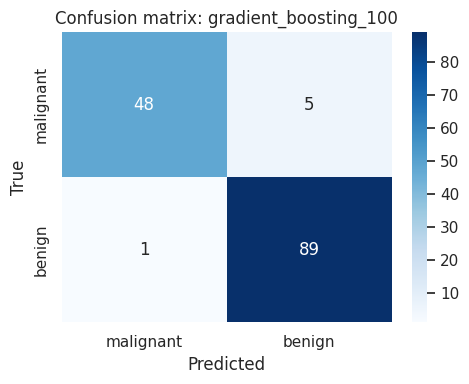

In [7]:
explained_model_name = "gradient_boosting_100"
explained_model = models[explained_model_name]
explained_model.fit(X_train, y_train)

y_pred = explained_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Confusion matrix: {explained_model_name}")
plt.tight_layout()
plt.show()


## Task 3 - Compute SHAP Global Importance

Implement `compute_shap_importance(model, X_explain, feature_names)`.

Use SHAP values to return a dataframe with columns:

- `feature`
- `mean_abs_shap`
- `rank`

Sort by `mean_abs_shap` descending. Rank starts at 1.

Implementation notes:

- Use `shap.TreeExplainer(model)` or `shap.Explainer(model, X_explain)`.
- Binary classifiers sometimes return a list or a 3D array of SHAP values. Your function should reduce this to one matrix of shape `(n_samples, n_features)` before taking absolute means.


In [13]:
def compute_shap_importance(model, X_explain: pd.DataFrame, feature_names: list[str]) -> pd.DataFrame:
    """Compute global feature importance from mean absolute SHAP values."""
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_explain)

    if isinstance(shap_values, list):
        values = np.asarray(shap_values[-1])
    else:
        values = np.asarray(shap_values)

    if values.ndim == 3:
        if values.shape[1] == len(feature_names):
            values = values[:, :, -1]
        else:
            values = values[-1]

    mean_abs = np.abs(values).mean(axis=0)
    table = pd.DataFrame({"feature": feature_names, "mean_abs_shap": mean_abs})
    table = table.sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
    table["rank"] = np.arange(1, len(table) + 1)
    return table[["feature", "mean_abs_shap", "rank"]]


In [14]:
# Self-check: Task 3
shap_importance = compute_shap_importance(explained_model, X_test, feature_names)

assert isinstance(shap_importance, pd.DataFrame)
assert list(shap_importance.columns) == ["feature", "mean_abs_shap", "rank"]
assert len(shap_importance) == len(feature_names)
assert shap_importance["mean_abs_shap"].ge(0).all()
assert shap_importance["mean_abs_shap"].is_monotonic_decreasing
assert shap_importance["rank"].tolist() == list(range(1, len(feature_names) + 1))

print("Task 3 passed")
shap_importance.head(10)


Task 3 passed


,feature,mean_abs_shap,rank
0,worst area,1.219683,1
1,worst concave points,1.204328,2
2,worst perimeter,0.932602,3
3,worst radius,0.926089,4
4,area error,0.630402,5
5,worst texture,0.581031,6
6,mean concave points,0.456390,7
7,worst smoothness,0.333724,8
8,mean area,0.332176,9
9,worst concavity,0.309895,10


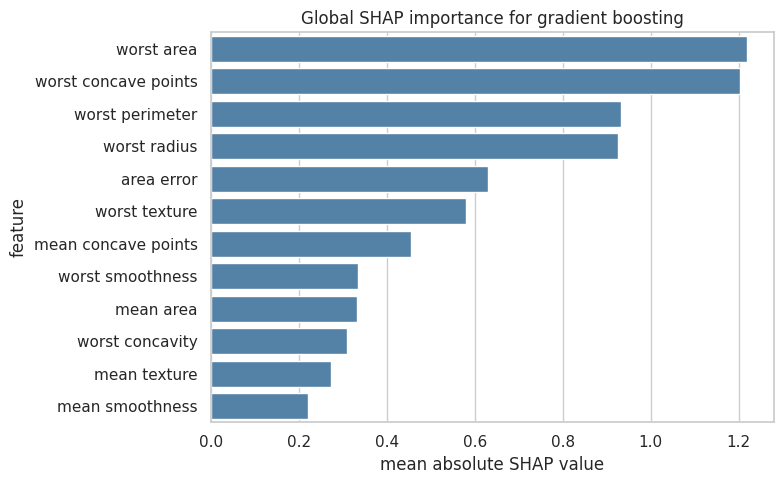

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_df = shap_importance.head(12)
sns.barplot(data=plot_df, x="mean_abs_shap", y="feature", color="steelblue", ax=ax)
ax.set_title("Global SHAP importance for gradient boosting")
ax.set_xlabel("mean absolute SHAP value")
plt.tight_layout()
plt.show()


## Guided Analysis: Read the SHAP Summary Plot

The bar chart above is a compact ranking. The SHAP summary plot below carries more information: each point is a sample, horizontal position is SHAP impact, and colour is the feature value. Use this plot to decide whether the model relies on a few dominant features or a broad set of features.


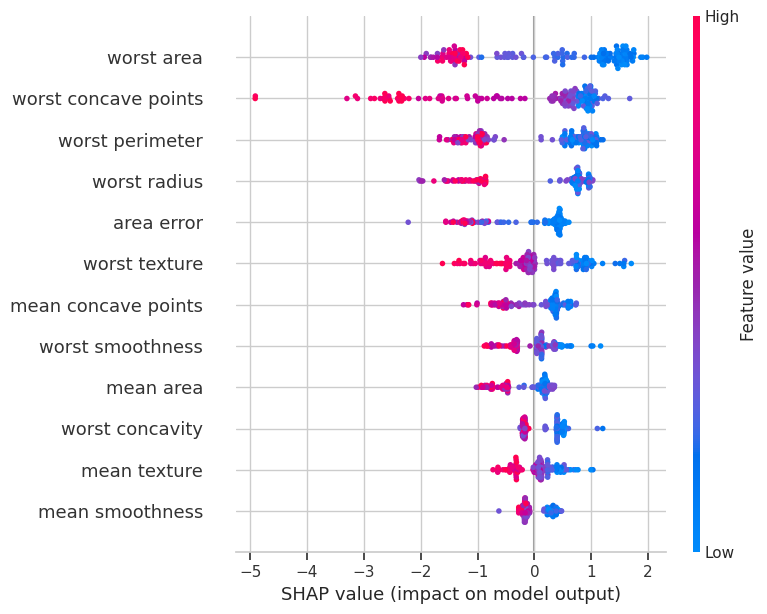

In [16]:
explainer = shap.TreeExplainer(explained_model)
raw_shap_values = explainer.shap_values(X_test)

# Handle SHAP output shape differences across versions/models.
if isinstance(raw_shap_values, list):
    shap_values_for_plot = raw_shap_values[-1]
elif getattr(raw_shap_values, "ndim", 0) == 3:
    shap_values_for_plot = raw_shap_values[:, :, -1]
else:
    shap_values_for_plot = raw_shap_values

shap.summary_plot(shap_values_for_plot, X_test, feature_names=feature_names, max_display=12)


## Task 4 - Retrain on SHAP-Selected Features

Implement `evaluate_feature_subset(model, X_train, X_test, y_train, y_test, selected_features)`.

Fit a fresh copy of the model using only `selected_features`, then return a one-row dataframe with columns. The `model` value should clearly identify the SHAP-selected subset, for example `gradient_boosting_shap_top6`:

- `model`
- `n_features`
- `accuracy`
- `f1_macro`
- `roc_auc`
- `fit_time_sec`

This is the modelling decision driven by SHAP: if the top SHAP features retain most of the score, the explanation led to a simpler model.


In [17]:
def evaluate_feature_subset(model, X_train, X_test, y_train, y_test, selected_features: list[str]) -> pd.DataFrame:
    """Retrain a classifier on selected features and return held-out metrics."""
    subset_model = clone(model)
    start = perf_counter()
    subset_model.fit(X_train[selected_features], y_train)
    fit_time = perf_counter() - start

    predictions = subset_model.predict(X_test[selected_features])
    probabilities = subset_model.predict_proba(X_test[selected_features])[:, 1]
    model_name = f"{subset_model.__class__.__name__}_shap_top_{len(selected_features)}"

    return pd.DataFrame(
        [
            {
                "model": model_name,
                "n_features": len(selected_features),
                "accuracy": float(accuracy_score(y_test, predictions)),
                "f1_macro": float(f1_score(y_test, predictions, average="macro")),
                "roc_auc": float(roc_auc_score(y_test, probabilities)),
                "fit_time_sec": float(fit_time),
            }
        ],
        columns=["model", "n_features", "accuracy", "f1_macro", "roc_auc", "fit_time_sec"],
    )


In [18]:
# Self-check: Task 4
selected_features = shap_importance.head(TOP_K_FEATURES)["feature"].tolist()
subset_results = evaluate_feature_subset(
    GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=RANDOM_STATE),
    X_train,
    X_test,
    y_train,
    y_test,
    selected_features,
)

assert isinstance(subset_results, pd.DataFrame)
assert list(subset_results.columns) == ["model", "n_features", "accuracy", "f1_macro", "roc_auc", "fit_time_sec"]
assert len(subset_results) == 1
assert subset_results["n_features"].iloc[0] == TOP_K_FEATURES
assert "shap_top" in subset_results["model"].iloc[0], "Name the model as a SHAP-selected feature subset"
assert subset_results[["accuracy", "f1_macro", "roc_auc"]].iloc[0].between(0, 1).all()

print("Task 4 passed")
print("Selected features:", selected_features)
subset_results


Task 4 passed
Selected features: ['worst area', 'worst concave points', 'worst perimeter', 'worst radius', 'area error', 'worst texture']


,model,n_features,accuracy,f1_macro,roc_auc,fit_time_sec
0,GradientBoostingClassifier_shap_top_6,6,0.944056,0.93956,0.990985,0.087513


## Local SHAP Check

Before accepting the compact model, inspect one individual prediction. Choose a false negative if one exists, because missing a malignant case is clinically costly. If no false negative exists, inspect the first test sample.


In [19]:
proba = explained_model.predict_proba(X_test)[:, 1]
local_df = X_test.copy()
local_df["true"] = y_test.values
local_df["pred"] = y_pred
local_df["p_benign"] = proba

false_negative = local_df[(local_df["true"] == 0) & (local_df["pred"] == 1)]
if len(false_negative) > 0:
    local_idx = false_negative.index[0]
    print("Inspecting false negative at index", local_idx)
else:
    local_idx = X_test.index[0]
    print("No false negative found; inspecting first test sample", local_idx)

row_pos = list(X_test.index).index(local_idx)
local_contrib = pd.DataFrame({
    "feature": feature_names,
    "feature_value": X_test.loc[local_idx].values,
    "shap_value": shap_values_for_plot[row_pos],
})
local_contrib["abs_shap"] = local_contrib["shap_value"].abs()
local_contrib = local_contrib.sort_values("abs_shap", ascending=False)
local_contrib.head(10)


Inspecting false negative at index 385


,feature,feature_value,shap_value,abs_shap
21,worst texture,31.71000,-1.039714,1.039714
20,worst radius,15.79000,0.900486,0.900486
1,mean texture,23.29000,-0.645518,0.645518
23,worst area,758.20000,0.583408,0.583408
4,mean smoothness,0.08682,0.468644,0.468644
27,worst concave points,0.13590,0.442693,0.442693
7,mean concave points,0.05271,-0.382411,0.382411
24,worst smoothness,0.13120,0.364913,0.364913
22,worst perimeter,102.20000,0.316012,0.316012
3,mean area,664.70000,0.314100,0.314100


## Task 5 - Benchmark Long Format

Implement `make_benchmark_long(results, week, dataset, task_type, target, split)`.

Convert model results into long benchmark format:

- `week`
- `dataset`
- `task_type`
- `target`
- `model`
- `metric`
- `score`
- `split`
- `notes`

Include numeric metric columns such as `accuracy`, `f1_macro`, and `roc_auc`. Do not include `fit_time_sec` or `n_features` as metrics.


In [20]:
def make_benchmark_long(
    results: pd.DataFrame,
    week: str,
    dataset: str,
    task_type: str,
    target: str,
    split: str,
) -> pd.DataFrame:
    """Convert classifier results to the cumulative benchmark long format."""
    excluded_columns = ["model", "fit_time_sec", "n_features"]
    metric_columns = [column for column in results.columns if column not in excluded_columns]
    rows = []

    for _, result in results.iterrows():
        for metric in metric_columns:
            if pd.isna(result[metric]):
                continue
            rows.append(
                {
                    "week": week,
                    "dataset": dataset,
                    "task_type": task_type,
                    "target": target,
                    "model": result["model"],
                    "metric": metric,
                    "score": float(result[metric]),
                    "split": split,
                    "notes": "boosting models; SHAP-selected subset included",
                }
            )

    columns = ["week", "dataset", "task_type", "target", "model", "metric", "score", "split", "notes"]
    return pd.DataFrame(rows, columns=columns)


In [21]:
subset_for_benchmark = subset_results.drop(columns=["n_features"])
all_results = pd.concat([model_results, subset_for_benchmark], ignore_index=True)
all_results = all_results.sort_values("f1_macro", ascending=False).reset_index(drop=True)

benchmark_long = make_benchmark_long(
    all_results,
    week="W06",
    dataset="Breast Cancer Wisconsin",
    task_type="classification",
    target="diagnosis",
    split="75_25_stratified_random_state_42",
)

expected_cols = ["week", "dataset", "task_type", "target", "model", "metric", "score", "split", "notes"]
assert list(benchmark_long.columns) == expected_cols
assert {"accuracy", "f1_macro", "roc_auc"}.issubset(set(benchmark_long["metric"]))
assert "fit_time_sec" not in set(benchmark_long["metric"])
assert "n_features" not in set(benchmark_long["metric"])
assert benchmark_long["score"].between(0, 1).all()

print("Task 5 passed")
benchmark_long.head(12)


Task 5 passed


,week,dataset,task_type,target,model,metric,score,split,notes
0,W06,Breast Cancer Wisconsin,classification,diagnosis,hist_gradient_boosting,accuracy,0.965035,75_25_stratified_random_state_42,boosting models; SHAP-selected subset included
1,W06,Breast Cancer Wisconsin,classification,diagnosis,hist_gradient_boosting,f1_macro,0.962067,75_25_stratified_random_state_42,boosting models; SHAP-selected subset included
2,W06,Breast Cancer Wisconsin,classification,diagnosis,hist_gradient_boosting,roc_auc,0.994130,75_25_stratified_random_state_42,boosting models; SHAP-selected subset included
3,W06,Breast Cancer Wisconsin,classification,diagnosis,random_forest_200,accuracy,0.958042,75_25_stratified_random_state_42,boosting models; SHAP-selected subset included
4,W06,Breast Cancer Wisconsin,classification,diagnosis,random_forest_200,f1_macro,0.954670,75_25_stratified_random_state_42,boosting models; SHAP-selected subset included
5,W06,Breast Cancer Wisconsin,classification,diagnosis,random_forest_200,roc_auc,0.994864,75_25_stratified_random_state_42,boosting models; SHAP-selected subset included
6,W06,Breast Cancer Wisconsin,classification,diagnosis,gradient_boosting_100,accuracy,0.958042,75_25_stratified_random_state_42,boosting models; SHAP-selected subset included
7,W06,Breast Cancer Wisconsin,classification,diagnosis,gradient_boosting_100,f1_macro,0.954284,75_25_stratified_random_state_42,boosting models; SHAP-selected subset included
8,W06,Breast Cancer Wisconsin,classification,diagnosis,gradient_boosting_100,roc_auc,0.992453,75_25_stratified_random_state_42,boosting models; SHAP-selected subset included
9,W06,Breast Cancer Wisconsin,classification,diagnosis,decision_tree_depth_3,accuracy,0.944056,75_25_stratified_random_state_42,boosting models; SHAP-selected subset included


## Benchmark Wide View

The important comparison is now full boosted model vs SHAP-selected compact model, alongside the earlier baselines.


In [22]:
benchmark_wide = (
    benchmark_long
    .pivot_table(
        index=["dataset", "task_type", "target", "metric", "split"],
        columns="model",
        values="score",
        aggfunc="first",
    )
    .reset_index()
)
benchmark_wide.columns.name = None
benchmark_wide


,dataset,task_type,target,metric,split,GradientBoostingClassifier_shap_top_6,decision_tree_depth_3,dummy_most_frequent,gradient_boosting_100,hist_gradient_boosting,random_forest_200
0,Breast Cancer Wisconsin,classification,diagnosis,accuracy,75_25_stratified_random_state_42,0.944056,0.944056,0.629371,0.958042,0.965035,0.958042
1,Breast Cancer Wisconsin,classification,diagnosis,f1_macro,75_25_stratified_random_state_42,0.939560,0.939560,0.386266,0.954284,0.962067,0.954670
2,Breast Cancer Wisconsin,classification,diagnosis,roc_auc,75_25_stratified_random_state_42,0.990985,0.946331,0.500000,0.992453,0.994130,0.994864


## Reflection

Answer briefly, but concretely.

1. Which features did SHAP identify as most important? What does the summary plot say about high vs low values for at least one of them?
2. How much performance did the SHAP-selected compact model lose or gain compared with the full gradient boosting model?
3. Based on the local SHAP explanation, what feature values most influenced the inspected prediction?
4. Did SHAP change what you would do next with this model or dataset?


## Challenge Tracks Optional

Choose zero, one, or more.

### Track A - Different Top-K
Repeat the SHAP-selected model with top 3, top 10, and top 15 features. Plot performance vs number of features.

### Track B - SHAP-Stability Check
Compute SHAP importance on two random halves of the test set. Are the top features stable?

### Track C - Compare Explanation Methods
Compare SHAP global importance with permutation importance. Where do they agree, and where do they disagree?


In [ ]:
# Optional challenge workspace
# Your code here
